# inspect_panderm_ha_patch_map.ipynb

This notebook is a walk-through of your current **HA fine-tuning** pipeline.

It shows, on a **single image + mask**:

1. how the image and mask are loaded
2. how the paired transform changes both
3. how PanDerm creates patch tokens
4. how the current HA script builds a **patch-wise class activation score map**
5. why the map is naturally **14 x 14** for a 224 x 224 image with patch size 16
6. how the mask is resized to map resolution first
7. how the penalized Dice / HA loss is computed step by step
8. what to verify before changing the training code

**Important note**

The supplied `modeling_finetune.py` does **not** currently expose `return_patch_tokens=True` in `VisionTransformer.forward(...)`.
So this notebook manually reconstructs the forward pass to inspect the exact tensors that your HA code wants to use.


In [2]:
from pathlib import Path
import inspect
import sys
import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from PIL import Image
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)


DEVICE: cpu


## Config

Set these paths to your local repo.

In [3]:
REPO_ROOT = Path('/Users/choekyelnyungmartsang/Developer/master-thesis').resolve()
PANDERM_CLASSIFICATION_DIR = REPO_ROOT / 'external' / 'PanDerm' / 'classification'

CSV_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'ham_segmentation_overlap.csv'
ROOT_PATH = REPO_ROOT / 'data' / 'HAM10000'
PRETRAINED_CHECKPOINT = REPO_ROOT / 'external' / 'weights' / 'panderm_bb_data6_checkpoint-499.pth'
FINETUNED_CHECKPOINT = REPO_ROOT / 'external' / 'weights' / 'checkpoint-best-ham.pth'

NB_CLASSES = 7
INPUT_SIZE = 224
IMAGE_KEY = 'image_rel_path'
MASK_KEY = 'mask_rel_path'
SEED = 1

for p in [PANDERM_CLASSIFICATION_DIR, CSV_PATH, ROOT_PATH, PRETRAINED_CHECKPOINT, FINETUNED_CHECKPOINT]:
    print(p, 'exists:', p.exists())

if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))


/Users/choekyelnyungmartsang/Developer/master-thesis/external/PanDerm/classification exists: True
/Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/ham_segmentation_overlap.csv exists: True
/Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000 exists: True
/Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth exists: True
/Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/checkpoint-best-ham.pth exists: True


In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from models.modeling_finetune import panderm_base_patch16_224_finetune

tmp_model = panderm_base_patch16_224_finetune(
    pretrained=False,
    num_classes=NB_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.2,
    attn_drop_rate=0.0,
    drop_block_rate=None,
    use_mean_pooling=True,
    init_scale=0.001,
    use_rel_pos_bias=True,
    init_values=0.1,
    lin_probe=False,
)

print('VisionTransformer.forward signature:')
print(inspect.signature(tmp_model.forward))

dummy = torch.randn(1, 3, 224, 224)
out = tmp_model(dummy, return_patch_tokens=True)

print('\nReturned object type:', type(out))
if isinstance(out, dict):
    print('Returned keys:', out.keys())
    print('logits shape:', out['logits'].shape)
    print('patch_tokens shape:', out['patch_tokens'].shape)
else:
    print('Unexpected output:', out)

/Users/choekyelnyungmartsang/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/choekyelnyungmartsang/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/choekyelnyungmartsang/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403251597/work/aten/src/ATen/native/TensorShape.cpp:3550.)
  return _VF.me

VisionTransformer.forward signature:
(x, return_patch_tokens=False)

Returned object type: <class 'dict'>
Returned keys: dict_keys(['logits', 'patch_tokens'])
logits shape: torch.Size([1, 7])
patch_tokens shape: torch.Size([1, 196, 768])


## Paired transform copied from your HA script

This keeps image and mask spatially aligned.

In [5]:
class SimplePairedDermTransform:
    def __init__(self, input_size=224, train=False, mean=None, std=None):
        self.input_size = input_size
        self.train = train
        self.mean = mean if mean is not None else [0.485, 0.456, 0.406]
        self.std = std if std is not None else [0.229, 0.224, 0.225]

    def _mask_to_tensor(self, mask):
        mask = TF.pil_to_tensor(mask).float()
        if mask.shape[0] > 1:
            mask = mask[:1]
        if mask.max() > 1:
            mask = mask / 255.0
        return mask

    def __call__(self, image, mask):
        image = TF.resize(image, 256, interpolation=InterpolationMode.BILINEAR, antialias=True)
        mask = TF.resize(mask, 256, interpolation=InterpolationMode.NEAREST)
        image = TF.center_crop(image, [self.input_size, self.input_size])
        mask = TF.center_crop(mask, [self.input_size, self.input_size])
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=self.mean, std=self.std)
        mask = self._mask_to_tensor(mask)
        mask = (mask > 0.5).float()
        return image, mask

paired_transform = SimplePairedDermTransform(input_size=INPUT_SIZE, train=False)


## Load one sample from the CSV

In [28]:
df = pd.read_csv(CSV_PATH)
print('CSV shape:', df.shape)
print('Columns:', list(df.columns))

# choose one row with a mask
row = df[df[MASK_KEY].notna()].iloc[12]
row


CSV shape: (10015, 7)
Columns: ['image_id', 'label', 'dx', 'split', 'image_rel_path', 'mask_rel_path', 'mask_found']


image_id                                               ISIC_0025033
label                                                             2
dx                                                              bkl
split                                                         train
image_rel_path                              images/ISIC_0025033.jpg
mask_rel_path     ../HAM10000_segmentations_lesion_tschandl/ISIC...
mask_found                                                        1
Name: 12, dtype: object

In [29]:
image_path = ROOT_PATH / row[IMAGE_KEY]
mask_path = ROOT_PATH / row[MASK_KEY]
label = int(row['label'])

image_pil = Image.open(image_path).convert('RGB')
mask_pil = Image.open(mask_path).convert('L')

print('Image path:', image_path)
print('Mask path :', mask_path)
print('Label     :', label)
print('Image size:', image_pil.size)
print('Mask size :', mask_pil.size)

mask_np = np.array(mask_pil)
print('Mask unique values:', np.unique(mask_np))


Image path: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images/ISIC_0025033.jpg
Mask path : /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/../HAM10000_segmentations_lesion_tschandl/ISIC_0025033_segmentation.png
Label     : 2
Image size: (600, 450)
Mask size : (600, 450)
Mask unique values: [  0 255]


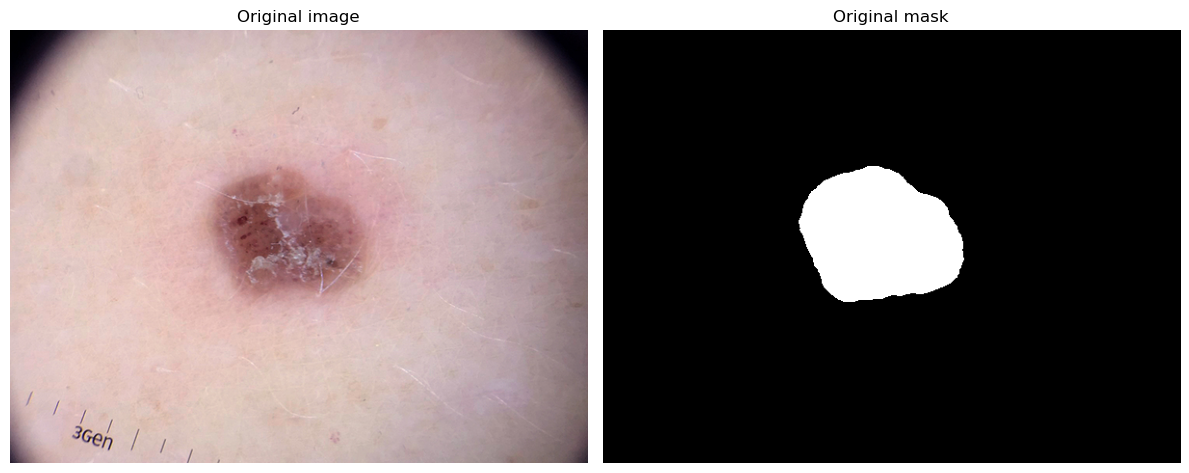

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(image_pil)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(mask_pil, cmap='gray')
ax[1].set_title('Original mask')
ax[1].axis('off')
plt.tight_layout()
plt.show()


## Apply the same transform as evaluation HA training

Transformed image tensor shape: (3, 224, 224)
Transformed mask tensor shape : (1, 224, 224)
Mask unique values after transform: tensor([0., 1.])


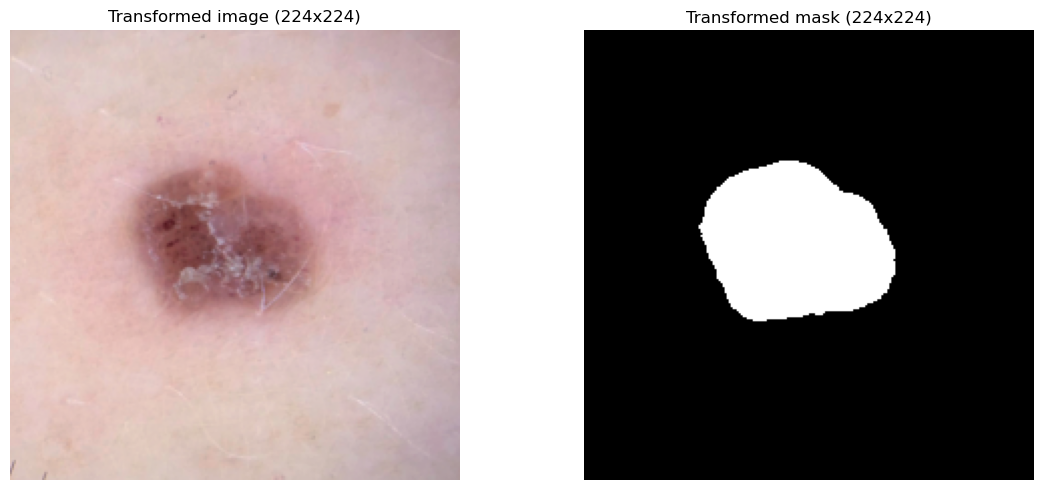

In [31]:
image_t, mask_t = paired_transform(image_pil, mask_pil)

print('Transformed image tensor shape:', tuple(image_t.shape))
print('Transformed mask tensor shape :', tuple(mask_t.shape))
print('Mask unique values after transform:', torch.unique(mask_t))

image_vis = image_t.permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_vis = np.clip(image_vis * std + mean, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(image_vis)
ax[0].set_title('Transformed image (224x224)')
ax[0].axis('off')

ax[1].imshow(mask_t.squeeze(0).cpu().numpy(), cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Transformed mask (224x224)')
ax[1].axis('off')
plt.tight_layout()
plt.show()


## Load the model

We load the fine-tune architecture.
Then we optionally load:
- the PanDerm foundation checkpoint
- your already fine-tuned HAM checkpoint

For inspection, either one is fine, but using the fine-tuned checkpoint is closer to your current HA runs.

In [9]:
def load_pretrained_for_finetune(model, ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location='cpu')
    checkpoint_model = None
    for key in ['model', 'module', 'state_dict']:
        if key in checkpoint:
            checkpoint_model = checkpoint[key]
            break
    if checkpoint_model is None:
        checkpoint_model = checkpoint

    checkpoint_model = checkpoint_model.copy()
    state_dict = model.state_dict()

    encoder_keys = [k for k in list(checkpoint_model.keys()) if k.startswith('encoder.')]
    if len(encoder_keys) > 0:
        for key in encoder_keys:
            new_key = key.replace('encoder.', '')
            checkpoint_model[new_key] = checkpoint_model[key]
        for key in encoder_keys:
            checkpoint_model.pop(key, None)

    for key in list(checkpoint_model.keys()):
        if key.startswith('decoder.') or key.startswith('teacher.'):
            checkpoint_model.pop(key, None)

    for key in list(checkpoint_model.keys()):
        if key.startswith('norm.'):
            new_key = key.replace('norm.', 'fc_norm.')
            checkpoint_model[new_key] = checkpoint_model[key]
            checkpoint_model.pop(key, None)

    for k in ['head.weight', 'head.bias']:
        if k in checkpoint_model and k in state_dict and checkpoint_model[k].shape != state_dict[k].shape:
            del checkpoint_model[k]

    msg = model.load_state_dict(checkpoint_model, strict=False)
    print('Foundation checkpoint load:', msg)


def load_finetuned_checkpoint_if_available(model, ckpt_path):
    if not ckpt_path.exists():
        print('Finetuned checkpoint not found, skipping:', ckpt_path)
        return
    checkpoint = torch.load(ckpt_path, map_location='cpu')
    state_dict = checkpoint['model'] if isinstance(checkpoint, dict) and 'model' in checkpoint else checkpoint
    msg = model.load_state_dict(state_dict, strict=False)
    print('Finetuned checkpoint load:', msg)


model = panderm_base_patch16_224_finetune(
    pretrained=False,
    num_classes=NB_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.2,
    attn_drop_rate=0.0,
    drop_block_rate=None,
    use_mean_pooling=True,
    init_scale=0.001,
    use_rel_pos_bias=True,
    init_values=0.1,
    lin_probe=False,
)

load_pretrained_for_finetune(model, PRETRAINED_CHECKPOINT)
load_finetuned_checkpoint_if_available(model, FINETUNED_CHECKPOINT)
model = model.to(DEVICE)
model.eval()

print('Patch grid:', model.patch_embed.patch_shape)
print('Head weight shape:', tuple(model.head.weight.shape))


Foundation checkpoint load: _IncompatibleKeys(missing_keys=['blocks.0.attn.relative_position_bias_table', 'blocks.0.attn.relative_position_index', 'blocks.1.attn.relative_position_bias_table', 'blocks.1.attn.relative_position_index', 'blocks.2.attn.relative_position_bias_table', 'blocks.2.attn.relative_position_index', 'blocks.3.attn.relative_position_bias_table', 'blocks.3.attn.relative_position_index', 'blocks.4.attn.relative_position_bias_table', 'blocks.4.attn.relative_position_index', 'blocks.5.attn.relative_position_bias_table', 'blocks.5.attn.relative_position_index', 'blocks.6.attn.relative_position_bias_table', 'blocks.6.attn.relative_position_index', 'blocks.7.attn.relative_position_bias_table', 'blocks.7.attn.relative_position_index', 'blocks.8.attn.relative_position_bias_table', 'blocks.8.attn.relative_position_index', 'blocks.9.attn.relative_position_bias_table', 'blocks.9.attn.relative_position_index', 'blocks.10.attn.relative_position_bias_table', 'blocks.10.attn.relativ

## Manual forward pass to recover patch tokens

This reproduces the logic of `VisionTransformer.forward_features(...)`, but also returns the patch tokens.

Important:
- `x[:, 0]` is the CLS token
- `x[:, 1:, :]` are the patch tokens
- for 224x224 with patch size 16, there are `14 x 14 = 196` patch tokens

In [10]:
@torch.no_grad()
def forward_with_patch_tokens(model, x):
    x = model.patch_embed(x)
    batch_size, seq_len, _ = x.size()

    cls_tokens = model.cls_token.expand(batch_size, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)

    if model.pos_embed is not None:
        x = x + model.pos_embed.expand(batch_size, -1, -1).type_as(x).to(x.device).clone().detach()

    x = model.pos_drop(x)
    rel_pos_bias = model.rel_pos_bias() if model.rel_pos_bias is not None else None
    for blk in model.blocks:
        x = blk(x, rel_pos_bias=rel_pos_bias)
    x = model.norm(x)

    patch_tokens = x[:, 1:, :]

    if model.fc_norm is not None:
        pooled = model.fc_norm(patch_tokens.mean(1))
    else:
        pooled = x[:, 0]

    logits = model.head(pooled)
    return logits, pooled, patch_tokens


x = image_t.unsqueeze(0).to(DEVICE)
logits, pooled, patch_tokens = forward_with_patch_tokens(model, x)

print('logits shape      :', tuple(logits.shape))
print('pooled shape      :', tuple(pooled.shape))
print('patch_tokens shape:', tuple(patch_tokens.shape))
print('Expected patch count:', model.patch_embed.patch_shape[0] * model.patch_embed.patch_shape[1])


logits shape      : (1, 7)
pooled shape      : (1, 768)
patch_tokens shape: (1, 196, 768)
Expected patch count: 196


## What "patch-wise class activation score" means in your current HA code

For the true class, your code takes:

- each patch token vector of shape `D`
- the classifier weight vector for the target class, also shape `D`
- computes a dot product

That gives one scalar per patch.

So each patch gets a score:

\[
score(patch_j, class_i) = \langle token_j, w_i \rangle
\]

Then:
- apply ReLU
- reshape the 196 scores into a `14 x 14` map
- min-max normalize the map into `[0, 1]`


In [11]:
def minmax_normalize_map(attn_map, eps=1e-6):
    b = attn_map.shape[0]
    flat = attn_map.view(b, -1)
    min_v = flat.min(dim=1, keepdim=True)[0].view(b, 1, 1)
    max_v = flat.max(dim=1, keepdim=True)[0].view(b, 1, 1)
    return (attn_map - min_v) / (max_v - min_v + eps)


def build_cls_patch_map(model, patch_tokens, target):
    head_weight = model.head.weight               # [C, D]
    selected_weight = head_weight[target]         # [B, D]
    patch_scores = (patch_tokens * selected_weight.unsqueeze(1)).sum(dim=-1)
    patch_scores = F.relu(patch_scores)
    h, w = model.patch_embed.patch_shape
    patch_map = patch_scores.view(patch_scores.shape[0], h, w)
    patch_map = minmax_normalize_map(patch_map)
    return patch_scores, patch_map


target = torch.tensor([label], device=DEVICE, dtype=torch.long)
patch_scores, patch_map = build_cls_patch_map(model, patch_tokens, target)

print('Classifier head shape:', tuple(model.head.weight.shape))
print('Selected class weight shape:', tuple(model.head.weight[target].shape))
print('Patch scores shape:', tuple(patch_scores.shape))
print('Patch map shape:', tuple(patch_map.shape))
print('Patch map min/max:', patch_map.min().item(), patch_map.max().item())


Classifier head shape: (7, 768)
Selected class weight shape: (1, 768)
Patch scores shape: (1, 196)
Patch map shape: (1, 14, 14)
Patch map min/max: 0.0 1.0


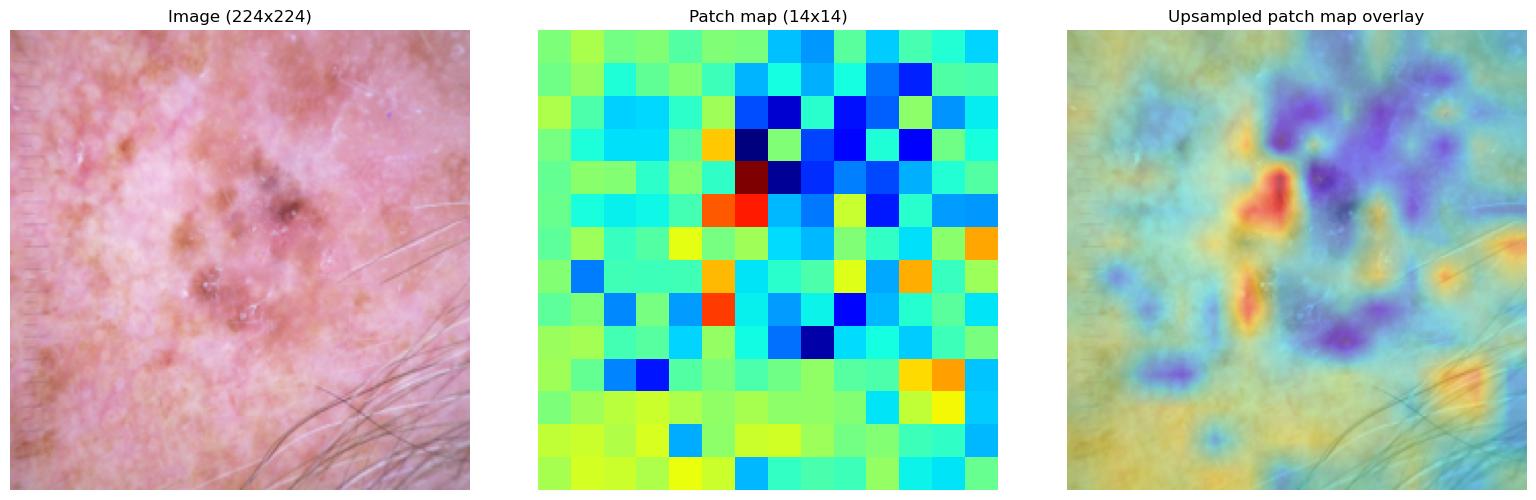

In [12]:
patch_map_np = patch_map[0].detach().cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(image_vis)
ax[0].set_title('Image (224x224)')
ax[0].axis('off')

ax[1].imshow(patch_map_np, cmap='jet')
ax[1].set_title('Patch map (14x14)')
ax[1].axis('off')

patch_map_up = F.interpolate(patch_map.unsqueeze(1), size=(224, 224), mode='bilinear', align_corners=False)[0, 0].detach().cpu().numpy()
ax[2].imshow(image_vis)
ax[2].imshow(patch_map_up, cmap='jet', alpha=0.45)
ax[2].set_title('Upsampled patch map overlay')
ax[2].axis('off')

plt.tight_layout()
plt.show()


## Why the natural map resolution is 14 x 14

Because:

- image size = 224 x 224
- patch size = 16 x 16

So the patch grid is:

\[
224 / 16 = 14
\]

Thus the model naturally scores **14 x 14 patches**, not 224 x 224 pixels.

That is why it is safer to resize the mask **down** to 14 x 14 first, instead of forcing the patch map to behave like a true pixel map too early.

Original mask shape   : (1, 224, 224)
Resized mask shape    : (14, 14)
Resized mask uniques  : tensor([0., 1.])


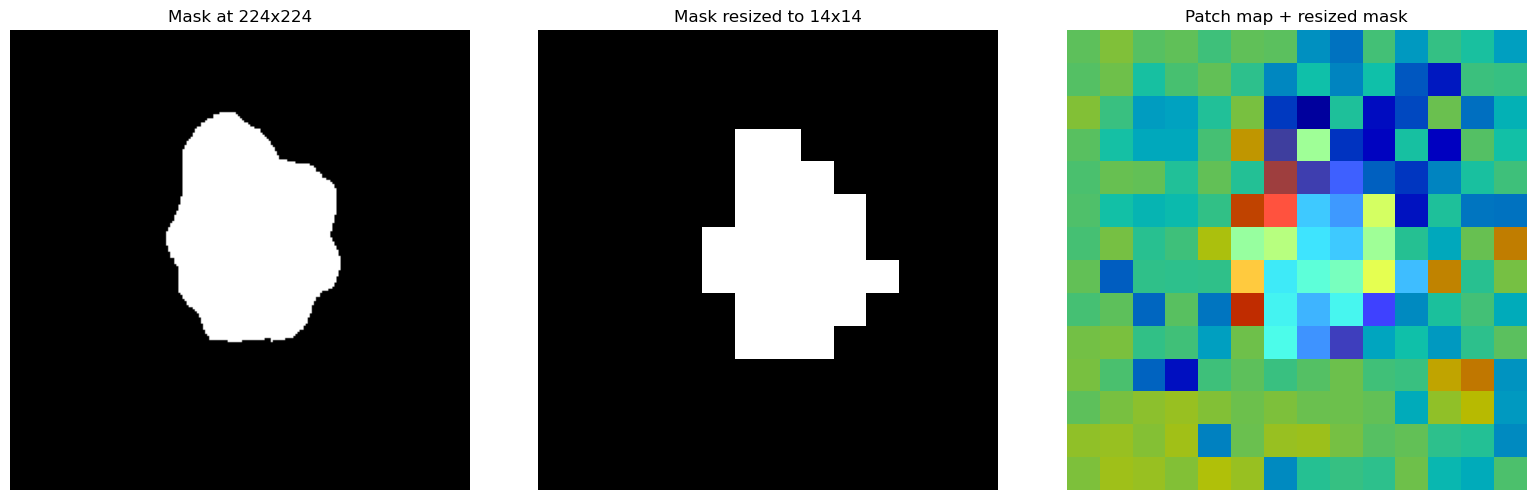

In [13]:
resized_mask = F.interpolate(mask_t.unsqueeze(0).float(), size=patch_map.shape[-2:], mode='nearest').squeeze(0).squeeze(0)
resized_mask = (resized_mask > 0.5).float()

print('Original mask shape   :', tuple(mask_t.shape))
print('Resized mask shape    :', tuple(resized_mask.shape))
print('Resized mask uniques  :', torch.unique(resized_mask))

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(mask_t.squeeze(0).cpu().numpy(), cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Mask at 224x224')
ax[0].axis('off')

ax[1].imshow(resized_mask.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Mask resized to 14x14')
ax[1].axis('off')

ax[2].imshow(patch_map_np, cmap='jet')
ax[2].imshow(resized_mask.cpu().numpy(), cmap='gray', alpha=0.25, vmin=0, vmax=1)
ax[2].set_title('Patch map + resized mask')
ax[2].axis('off')

plt.tight_layout()
plt.show()


## HA / penalized Dice loss step by step

In [14]:
def penalized_dice_terms(pred, target, fp_weight=1.0, eps=1e-6):
    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum(dim=(1, 2))
    pred_sum = pred.sum(dim=(1, 2))
    target_sum = target.sum(dim=(1, 2))
    false_positive_mass = (pred * (1.0 - target)).sum(dim=(1, 2))

    dice = (2.0 * intersection + eps) / (pred_sum + target_sum + fp_weight * false_positive_mass + eps)
    loss = 1.0 - dice.mean()
    return {
        'intersection': intersection,
        'pred_sum': pred_sum,
        'target_sum': target_sum,
        'false_positive_mass': false_positive_mass,
        'dice': dice,
        'loss': loss,
    }


terms = penalized_dice_terms(patch_map, resized_mask.unsqueeze(0), fp_weight=1.0)
for k, v in terms.items():
    if torch.is_tensor(v):
        print(k, v.detach().cpu().numpy())
    else:
        print(k, v)


intersection [10.510151]
pred_sum [84.639145]
target_sum [27.]
false_positive_mass [74.129]
dice [0.11315344]
loss 0.88684654


### Interpretation

- `intersection`: patch-map mass that falls **inside** the lesion mask
- `pred_sum`: total patch-map mass
- `target_sum`: total lesion area at patch resolution
- `false_positive_mass`: patch-map mass **outside** the lesion mask
- `dice`: overlap score after false-positive penalty
- `loss = 1 - dice`

So the HA loss says:

> put more class evidence inside the lesion region and reduce evidence outside it


## Optional: compare multiple class maps on the same image

This helps you see how class-specific the current patch-score mechanism is.

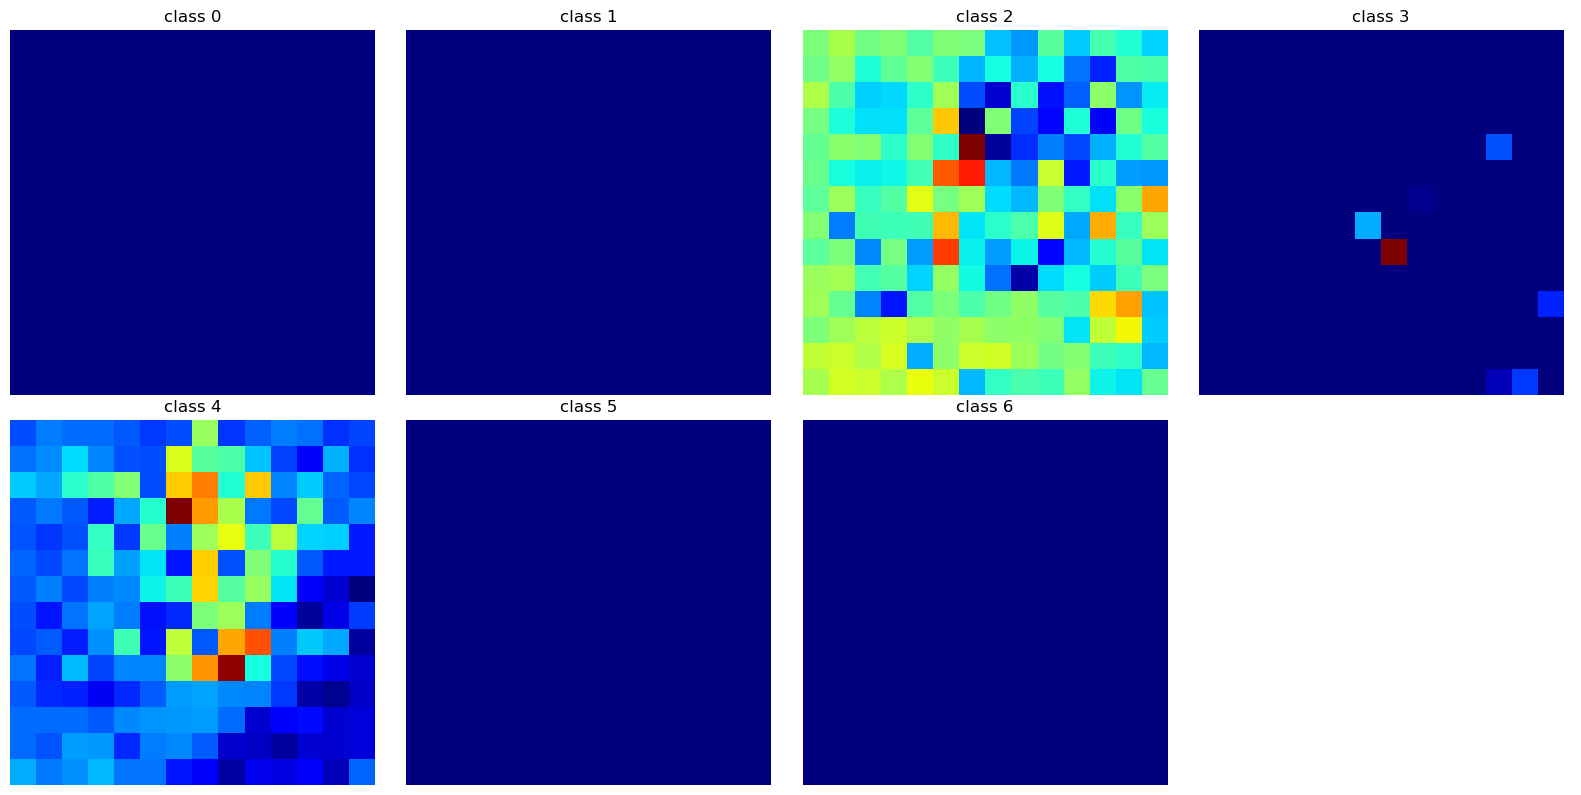

In [15]:
num_show = min(NB_CLASSES, 7)
fig, ax = plt.subplots(2, int(np.ceil(num_show / 2)), figsize=(16, 8))
ax = np.array(ax).reshape(-1)

for cls_idx in range(num_show):
    t = torch.tensor([cls_idx], device=DEVICE)
    _, cls_map = build_cls_patch_map(model, patch_tokens, t)
    ax[cls_idx].imshow(cls_map[0].detach().cpu().numpy(), cmap='jet')
    ax[cls_idx].set_title(f'class {cls_idx}')
    ax[cls_idx].axis('off')

for j in range(num_show, len(ax)):
    ax[j].axis('off')

plt.tight_layout()
plt.show()


## What this notebook tells you

Your current HA fine-tuning is not using native transformer attention yet.

It is using a **class-specific patch score map**:

1. get patch tokens from the ViT
2. for the chosen class, take the classifier weight vector
3. score each patch by dot product with that class vector
4. ReLU + reshape + normalize to get a spatial map
5. resize the binary lesion mask down to the same patch resolution
6. compute penalized Dice overlap

This is a coherent first HA design.

It is just different from the paper's decoder cross-attention map design.

## First code changes I would make before deeper experiments

1. **Make the model expose patch tokens directly**
   - add `return_patch_tokens=False` to `VisionTransformer.forward(...)`
   - when true, return a dict like `{'logits': logits, 'patch_tokens': patch_tokens}`

2. **Only after that, try exposing internal attention maps**
   - modify `Attention.forward(...)` to optionally return/store `attn`
   - then collect attention from one or more blocks

3. **Keep the mask-vs-map comparison at patch resolution first**
   - this part is already correct in your HA code

4. **Do not rely only on the notebook for decisions**
   - also inspect training logs: `cls_loss`, `ha_loss`, and `ha_lambda * ha_loss`


Visualization dataframe size: 10015
Chosen sample ids:


,image_id,dx,label,split,image_rel_path,mask_rel_path
0,ISIC_0027832,mel,4,train,images/ISIC_0027832.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...
1,ISIC_0025209,bkl,2,train,images/ISIC_0025209.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...
2,ISIC_0029998,nv,5,train,images/ISIC_0029998.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...
3,ISIC_0033068,mel,4,train,images/ISIC_0033068.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...
4,ISIC_0025261,nv,5,train,images/ISIC_0025261.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...
5,ISIC_0034216,mel,4,train,images/ISIC_0034216.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...


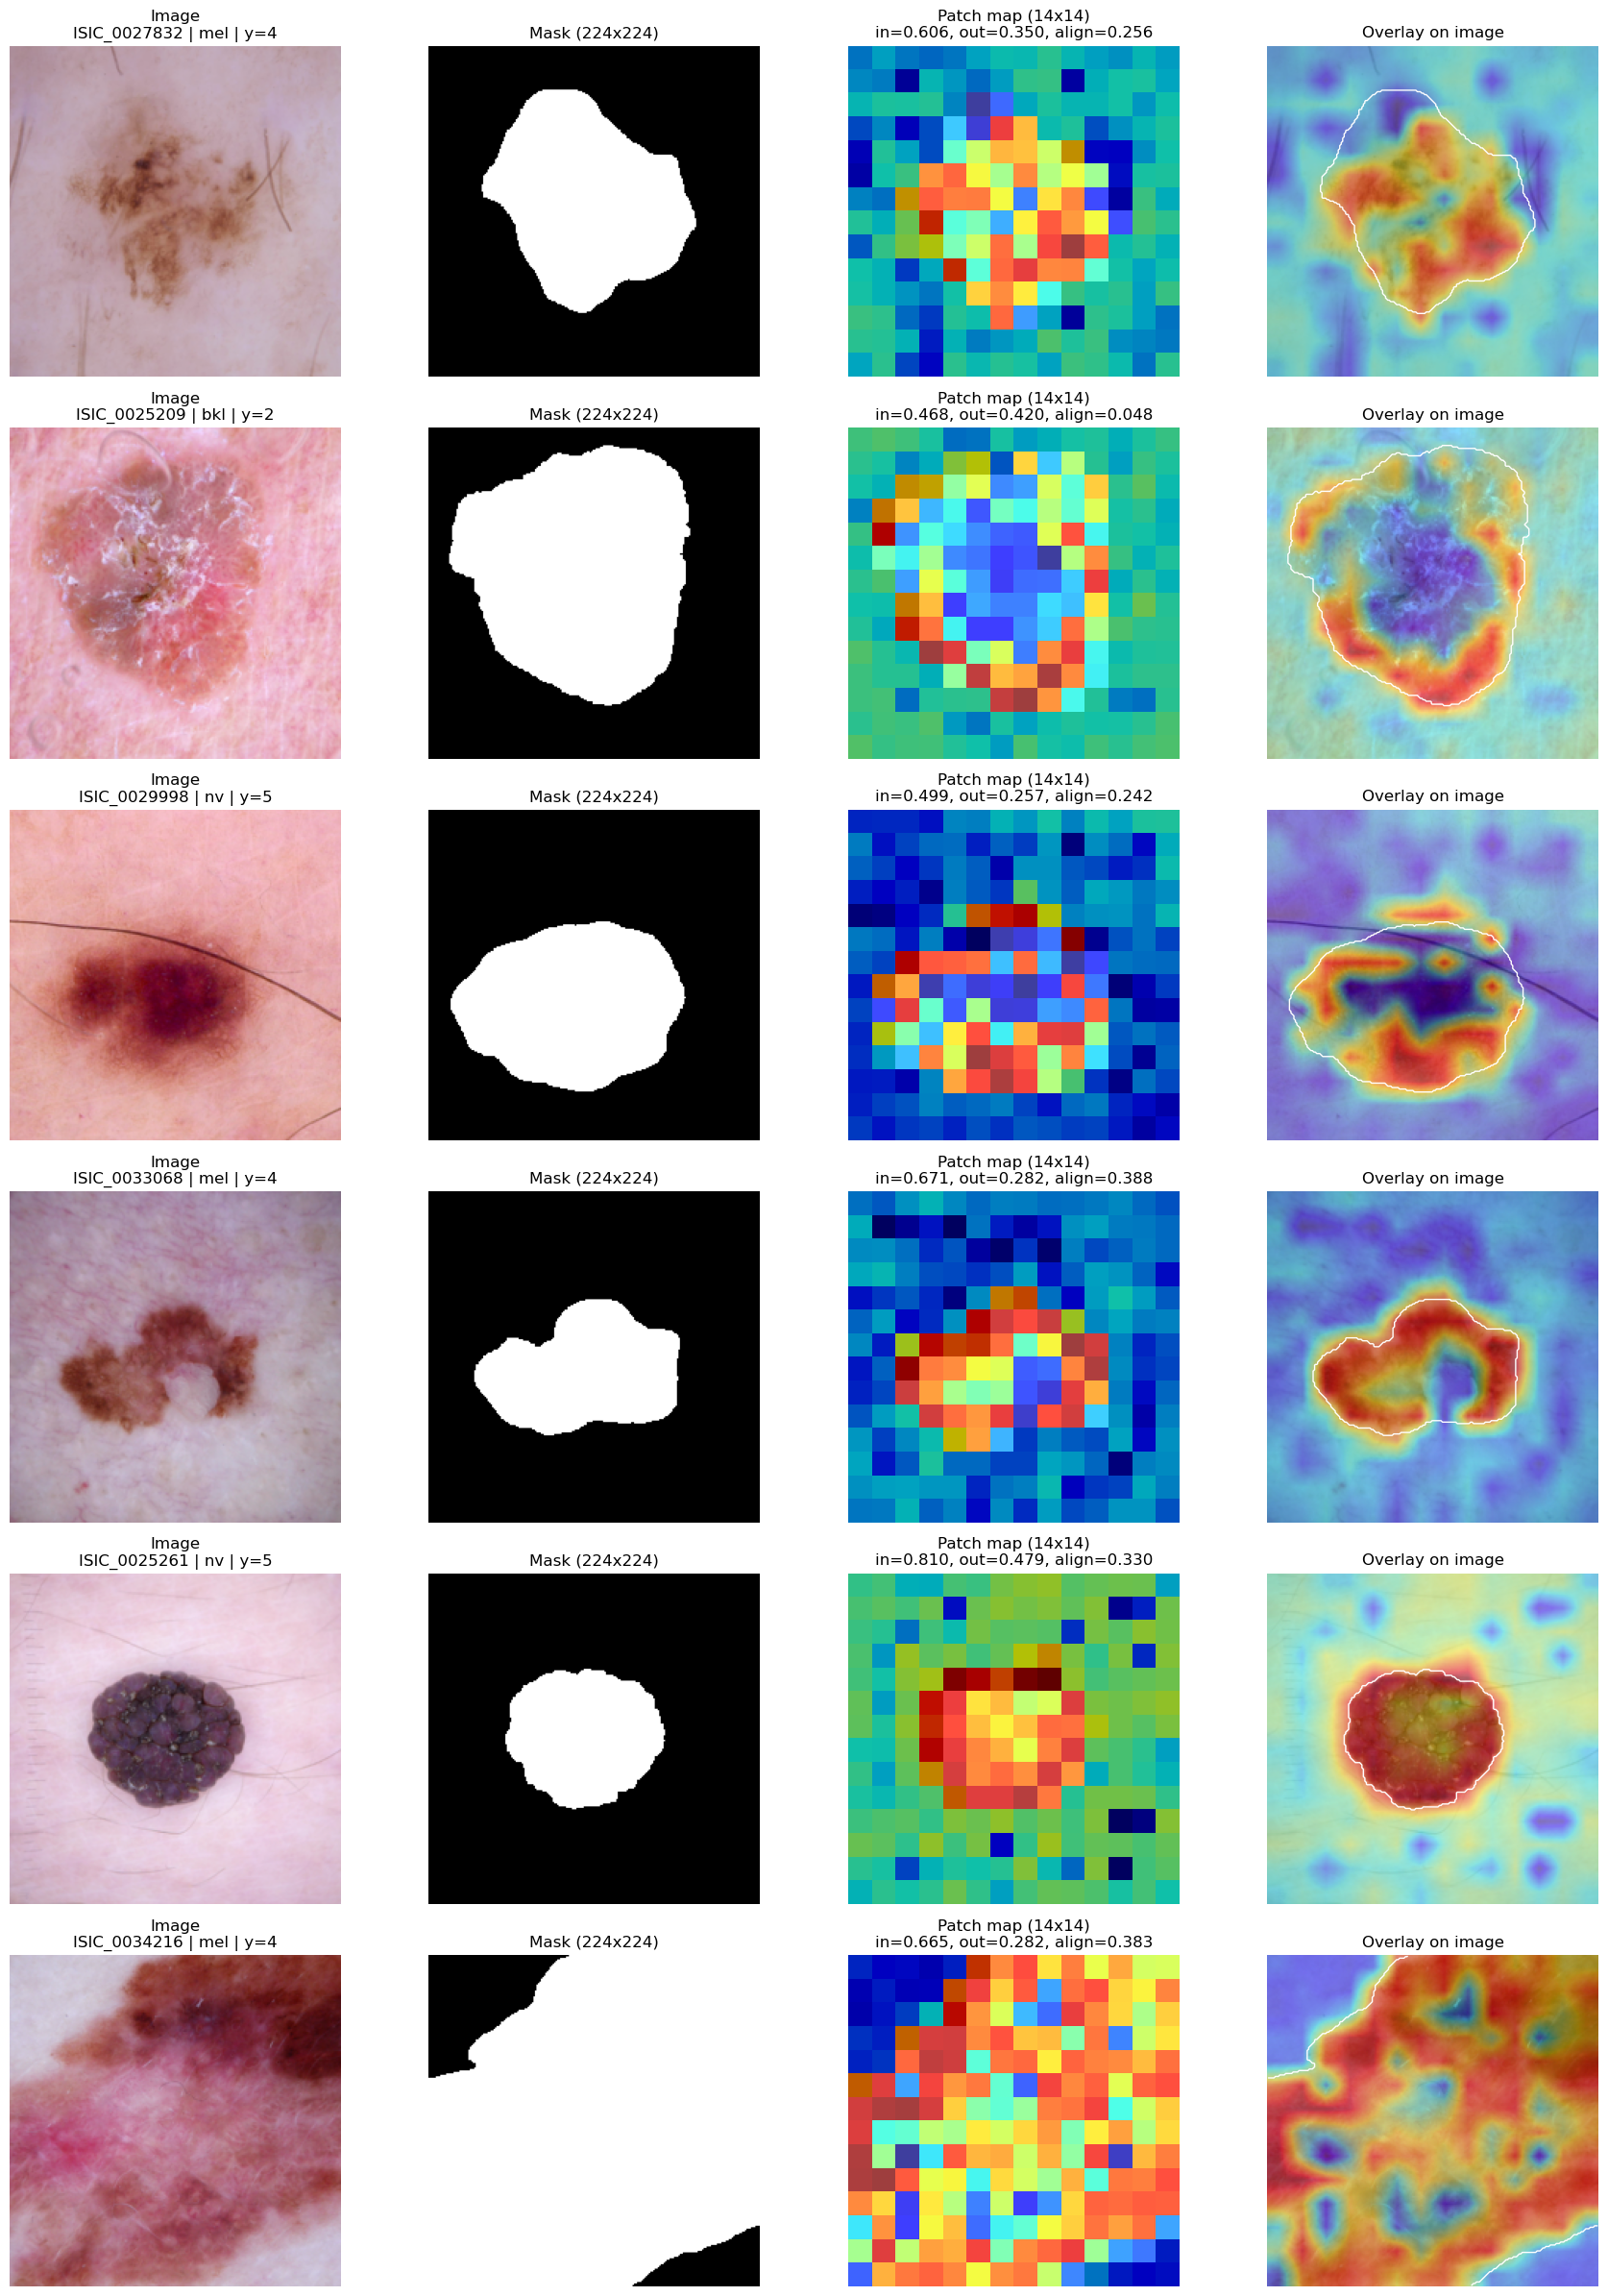

,image_id,dx,label,inside_mean,outside_mean,alignment,inside_mass,outside_mass,target_area,background_area
0,ISIC_0027832,mel,4,0.606028,0.350143,0.255885,32.725506,49.720253,54.0,142.0
1,ISIC_0025209,bkl,2,0.467615,0.419841,0.047774,38.344456,47.861889,82.0,114.0
2,ISIC_0029998,nv,5,0.498539,0.256895,0.241644,26.422586,36.736027,53.0,143.0
3,ISIC_0033068,mel,4,0.670712,0.282489,0.388223,23.474926,45.480747,35.0,161.0
4,ISIC_0025261,nv,5,0.809702,0.479291,0.330412,22.671665,80.520851,28.0,168.0
5,ISIC_0034216,mel,4,0.664561,0.281702,0.382859,112.310844,7.605953,169.0,27.0


In [16]:
# ============================================================
# Show 6 sample overlays for current HA patch-score map
# ============================================================

NUM_SAMPLES = 6
SPLIT = "train"   # choose from: "train", "val", "test"
ONLY_WITH_MASK = True

# optional: choose fixed rows manually by index from filtered dataframe
MANUAL_IDXS = None   # e.g. [0, 5, 10, 20, 30, 40]

# ------------------------------------------------------------
# helper: choose rows from dataframe by split
# ------------------------------------------------------------
df_vis = df.copy()

if SPLIT in df_vis.columns:
    df_vis = df_vis[df_vis["split"] == SPLIT].reset_index(drop=True)

if ONLY_WITH_MASK:
    df_vis = df_vis[df_vis[MASK_KEY].notna()].reset_index(drop=True)

print("Visualization dataframe size:", len(df_vis))

if MANUAL_IDXS is not None:
    chosen_rows = df_vis.iloc[MANUAL_IDXS].reset_index(drop=True)
else:
    chosen_rows = df_vis.sample(n=min(NUM_SAMPLES, len(df_vis)), random_state=42).reset_index(drop=True)

print("Chosen sample ids:")
display(chosen_rows[["image_id", "dx", "label", "split", IMAGE_KEY, MASK_KEY]].head(NUM_SAMPLES))


# ------------------------------------------------------------
# helper functions
# ------------------------------------------------------------
def denormalize_image(image_t):
    image_np = image_t.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_np = np.clip(image_np * std + mean, 0, 1)
    return image_np

def compute_alignment_stats(pred_map, target_mask, eps=1e-6):
    """
    pred_map: [H, W] in [0,1]
    target_mask: [H, W] binary
    """
    pred = pred_map.float()
    target = target_mask.float()

    inside_mass = (pred * target).sum().item()
    outside_mass = (pred * (1.0 - target)).sum().item()

    target_area = target.sum().item()
    background_area = (1.0 - target).sum().item()

    inside_mean = inside_mass / (target_area + eps)
    outside_mean = outside_mass / (background_area + eps)
    alignment = inside_mean - outside_mean

    return {
        "inside_mass": inside_mass,
        "outside_mass": outside_mass,
        "target_area": target_area,
        "background_area": background_area,
        "inside_mean": inside_mean,
        "outside_mean": outside_mean,
        "alignment": alignment,
    }


# ------------------------------------------------------------
# visualize
# ------------------------------------------------------------
model.eval()

num_show = min(NUM_SAMPLES, len(chosen_rows))
fig, axes = plt.subplots(num_show, 4, figsize=(18, 4 * num_show))

if num_show == 1:
    axes = np.expand_dims(axes, axis=0)

all_stats = []

with torch.no_grad():
    for r in range(num_show):
        row = chosen_rows.iloc[r]

        image_path = ROOT_PATH / row[IMAGE_KEY]
        mask_path = ROOT_PATH / row[MASK_KEY]
        label = int(row["label"])

        image_pil = Image.open(image_path).convert("RGB")
        mask_pil = Image.open(mask_path).convert("L")

        # same transform as HA pipeline
        image_t, mask_t = paired_transform(image_pil, mask_pil)

        x = image_t.unsqueeze(0).to(DEVICE)
        logits, pooled, patch_tokens = forward_with_patch_tokens(model, x)

        target = torch.tensor([label], device=DEVICE, dtype=torch.long)
        _, patch_map = build_cls_patch_map(model, patch_tokens, target)   # [1,14,14]

        # resize mask down to patch-map resolution
        resized_mask = F.interpolate(
            mask_t.unsqueeze(0).float(),
            size=patch_map.shape[-2:],
            mode="nearest"
        ).squeeze(0).squeeze(0)
        resized_mask = (resized_mask > 0.5).float()

        patch_map_cpu = patch_map[0].detach().cpu()
        resized_mask_cpu = resized_mask.detach().cpu()

        # upsample patch map for overlay
        patch_map_up = F.interpolate(
            patch_map.unsqueeze(1),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )[0, 0].detach().cpu().numpy()

        image_vis = denormalize_image(image_t)
        mask_vis = mask_t.squeeze(0).cpu().numpy()

        stats = compute_alignment_stats(patch_map_cpu, resized_mask_cpu)
        stats["image_id"] = row["image_id"]
        stats["dx"] = row["dx"]
        stats["label"] = label
        all_stats.append(stats)

        # ---- column 1: image
        axes[r, 0].imshow(image_vis)
        axes[r, 0].set_title(f"Image\n{row['image_id']} | {row['dx']} | y={label}")
        axes[r, 0].axis("off")

        # ---- column 2: transformed mask
        axes[r, 1].imshow(mask_vis, cmap="gray", vmin=0, vmax=1)
        axes[r, 1].set_title("Mask (224x224)")
        axes[r, 1].axis("off")

        # ---- column 3: patch map + resized mask
        axes[r, 2].imshow(patch_map_cpu.numpy(), cmap="jet", vmin=0, vmax=1)
        axes[r, 2].imshow(resized_mask_cpu.numpy(), cmap="gray", alpha=0.25, vmin=0, vmax=1)
        axes[r, 2].set_title(
            "Patch map (14x14)\n"
            f"in={stats['inside_mean']:.3f}, out={stats['outside_mean']:.3f}, "
            f"align={stats['alignment']:.3f}"
        )
        axes[r, 2].axis("off")

        # ---- column 4: overlay
        axes[r, 3].imshow(image_vis)
        axes[r, 3].imshow(patch_map_up, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        axes[r, 3].contour(mask_vis, levels=[0.5], colors="white", linewidths=1)
        axes[r, 3].set_title("Overlay on image")
        axes[r, 3].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# stats table
# ------------------------------------------------------------
stats_df = pd.DataFrame(all_stats)
display(stats_df[[
    "image_id", "dx", "label",
    "inside_mean", "outside_mean", "alignment",
    "inside_mass", "outside_mass", "target_area", "background_area"
]])